In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals

In [2]:
try:
    tensorflow_version
except Exception:
    pass

In [3]:
import tensorflow as tf

In [4]:
tf.__version__

'2.19.0'

In [5]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [6]:
!pip install -q imageio

In [7]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time

from IPython import display

In [8]:
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


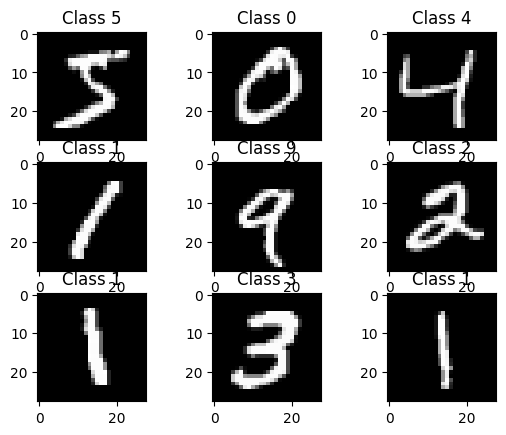

In [9]:
for i in range (9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i], cmap='gray', interpolation='none')
    plt.title("Class {}".format(train_labels[i]))

In [10]:
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

In [11]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

In [12]:
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
train_dataset

<_BatchDataset element_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None)>

In [13]:
def make_generator_model():

    model = tf.keras. Sequential ()
# neural network, where the layers go one after another
# Dense - type of neural network layer, all neurons of the previous level are connected to each neuron
# of the subsequent
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100, ) ) )
# BatchNormalization - type of normalisation; look at https://keras.io/layers/normalization/
    model. add (layers. BatchNormalization () )

# look at https://www.tensorflow.org/api_docs/python/tf/keras/layers/LeakyReLU
    model. add (layers.LeakyReLU( ))

    model.add (layers.Reshape( (7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256) # Note: None is the batch size
# Conv2DTranspose - Transposed convolution layer (sometimes called Deconvolution) ;
# look at https://keras.io/layers/convolutional/
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model. add(layers.BatchNormalization())
    model. add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model. add (layers. LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2),padding='same', use_bias=False, activation='tanh' ))
    assert model.output_shape == (None, 28, 28, 1)
    return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


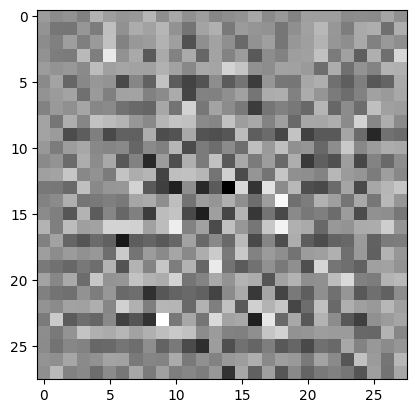

In [14]:
generator = make_generator_model()

noise = tf.random.normal([1,100])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')

In [15]:
generator?

In [16]:
def make_discriminator_model():
    model = tf.keras. Sequential ()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                            input_shape=[28, 28, 1]))
    model. add (layers. LeakyReLU())
# Dropout consists in randomly setting a fraction rate of input units to 0 at each update during training time,
# which helps prevent overfitting; Look at https://keras.io/layers/core/

    model.add(layers.Dropout(0.3))
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model. add (layers. LeakyReLU())
    model.add(layers.Dropout(0.3))
    model. add (layers. Flatten())
    model.add(layers.Dense(1))

    return model

In [17]:
discriminator = make_discriminator_model ( )
decision = discriminator (generated_image)
print (decision)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


tf.Tensor([[-0.00060828]], shape=(1, 1), dtype=float32)


In [18]:
discriminator?

In [19]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [20]:
def discriminator_loss(real_output, fake_output) :
    real_loss = cross_entropy (tf. ones_like(real_output) , real_output)
    fake_loss = cross_entropy (tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [21]:
def generator_loss ( fake_output) :
    return cross_entropy (tf.ones_like(fake_output), fake_output)

In [22]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [23]:
tf.keras.optimizers.Adam?

In [24]:
tf.train.Checkpoint?

In [25]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [26]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

In [27]:
tf.random.normal?

In [28]:
seed = tf.random.normal([num_examples_to_generate, noise_dim])

In [29]:
EPOCHS = 60

In [30]:
@tf.function
def train_step(images):
    noise = tf

In [31]:
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        for image_batch in dataset:
            train_step(image_batch)

        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)

        if(epoch + 1) % 15 == 0:
         checkpoint.save(file_prefix = checkpoint_prefix)

        print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

        display.clear_output(wait=True)
        generate_and_save_images(generator, epochs, seed)

In [32]:
def generate_and_save_images(model, epoch, test_input):

    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

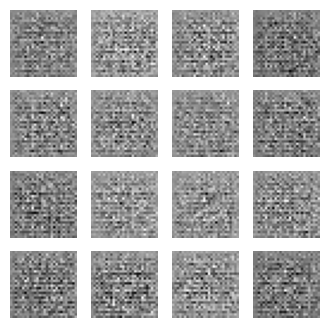

In [48]:
train(train_dataset, EPOCHS)

In [34]:
checkpoint.restore?

In [35]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

In [36]:
def display_image(epoch_no):
    return PIL.Image.open('image_at_epoch_{:04d}.png'.format(epoch_no))

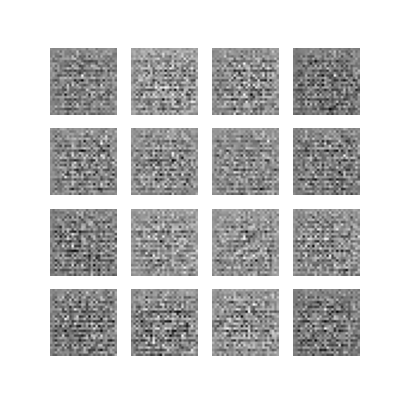

In [45]:
display_image(EPOCHS)

In [44]:
anim_file ='dcgan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
    filenames = glob.glob('image*.png')
    filenames = sorted(filenames)
    last = -1
    for i,filename in enumerate(filenames):
        frame = 2*(i**0.5)
        if round(frame) > round(last):
            last = frame
        else:
            continue
        image = imageio.imread(filename)
        writer.append_data(image)
    image = imageio.imread(filename)
    writer.append_data(image)

import IPython
if IPython.version_info > (6,2,0,''):
    display.Image(filename=anim_file)

/tmp/ipykernel_26188/3991223433.py:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
/tmp/ipykernel_26188/3991223433.py:15: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


In [39]:
try:
    from google.colab import files
except ImportError:
    pass
else:
    files.download(anim_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

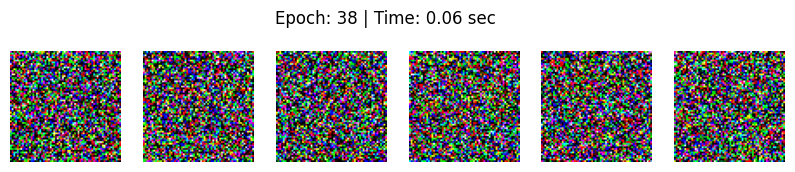

In [42]:
import matplotlib.pyplot as plt
import time
import torch

# -------- SETTINGS --------
epoch_to_capture = 38
start_time = time.time()

# -------- FUNCTION TO DISPLAY IMAGES --------
def show_generated_images(images, epoch, elapsed_time):
    images = images.detach().cpu()

    fig, axes = plt.subplots(1, 6, figsize=(10, 2))

    for i, ax in enumerate(axes):
        ax.imshow(images[i].permute(1, 2, 0))
        ax.axis('off')

    fig.suptitle(f"Epoch: {epoch} | Time: {elapsed_time:.2f} sec")

    # Save screenshot
    plt.savefig(f"epoch_{epoch}.png")
    plt.show()

# -------- TRAINING LOOP (SIMPLIFIED) --------
for epoch in range(1, 101):  # adjust to your total epochs

    # ---- your GAN training code here ----
    # generator training, discriminator training, etc.

    # Example: generate fake images (replace with your generator)
    noise = torch.randn(6, 100)   # adjust size if needed
    fake_images = torch.randn(6, 3, 64, 64)  # placeholder (replace with generator output)

    # ---- CAPTURE REQUIRED EPOCH ----
    if epoch == epoch_to_capture:
        elapsed_time = time.time() - start_time
        show_generated_images(fake_images, epoch, elapsed_time)

In [43]:
last_two_digits = 75

if last_two_digits <= 50:
    epoch = last_two_digits
else:
    import math
    epoch = math.ceil(last_two_digits / 50)

print("Required Epoch:", epoch)

Required Epoch: 2
